In [1]:
import pandas as pd 
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt 

### Exercise 16.1

In [129]:
def func_e1601(beta1, beta2, x):
    return beta1/(beta1-beta2)*(np.exp(-beta2*x)-np.exp(-beta1*x))

In [186]:
beta1_e1601, beta2_e1601 = np.meshgrid(np.logspace(-3,1,100), np.logspace(-3,1,100))#(np.linspace(0.001,40,1000),np.linspace(0.001,40,1000))
# X_e1601 = np.array([0.0625,0.125,0.25,0.5,1,2])
X_e1601 = np.array([1,2,4,5,6,7])
# y_e1601 = np.array([0.01,0.02,0.08,0.15,0.22,0.51])
y_e1601 = np.array([0.22,0.51,0.48,0.29,0.20,0.12])

In [187]:
beta1s = []
beta2s = []
sum_squares = []
for beta1, beta2 in zip(beta1_e1601.flatten(), beta2_e1601.flatten()):
    if beta1 != beta2:
        # print(beta1, beta2)#, func_e1601(beta1,beta2,X_e1601))
        # print(((y_e1601 - func_e1601(beta1,beta2,X_e1601))**2).sum())
        beta1s.append(beta1)
        beta2s.append(beta2)
        sum_squares.append(((y_e1601 - func_e1601(beta1,beta2,X_e1601))**2).sum().round(1))

        # fig,ax=plt.subplots()
        # ax.plot(np.linspace(0,7,701),func_e1601(beta1,beta2,np.linspace(0,7,701)))
        # ax.scatter(X_e1601,y_e1601)
        # ax.text(0.1,0.2,f'beta1: {beta1}',transform=ax.transAxes)
        # ax.text(0.1,0.1,f'beta2: {beta2}',transform=ax.transAxes)
betas_sum_squares = pd.DataFrame({
    'beta1s': beta1s,
    'beta2s': beta2s,
    'sum_squares': sum_squares,
})

In [188]:
betas_sum_squares.sort_values(by='sum_squares')


,beta1s,beta2s,sum_squares
6302,0.464159,0.351119,0.0
6303,0.509414,0.351119,0.0
6306,0.673415,0.351119,0.0
6404,0.613591,0.385353,0.0
6301,0.422924,0.351119,0.0
...,...,...,...
94,6.892612,0.001000,3.0
93,6.280291,0.001000,3.0
92,5.722368,0.001000,3.0
88,3.944206,0.001000,3.0


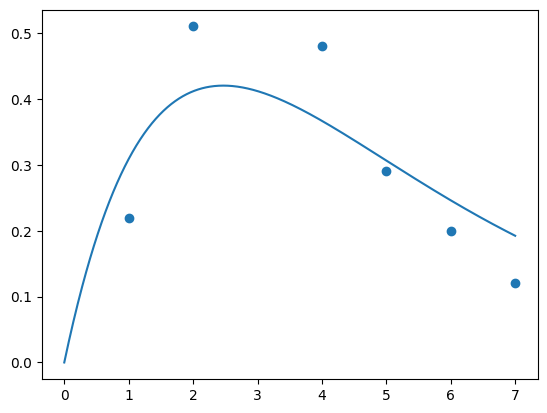

In [189]:
fig,ax=plt.subplots()
ax.plot(np.linspace(0,7,701),func_e1601(0.464,0.351, np.linspace(0,7,701)))
ax.scatter(X_e1601,y_e1601)

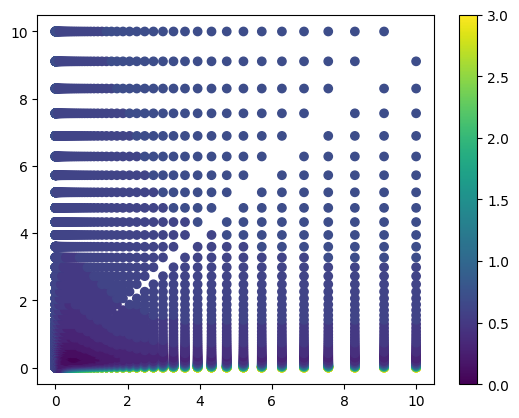

In [190]:
fig,ax = plt.subplots()
scatter = ax.scatter(betas_sum_squares['beta1s'], betas_sum_squares['beta2s'], c=betas_sum_squares['sum_squares'], cmap='viridis')
plt.colorbar(scatter)